# SpectraQ — MA-crossover validation

Four-stage Monte-Carlo Permutation Test (MCPT) framework.

This notebook decides whether the MA(fast, slow) crossover strategy that
the live agent runs has a *real* edge in SOL/USDC, or whether the
in-sample numbers are noise.

| Stage | What it tests | Acceptance |
|---|---|---|
| 1. In-sample optimization | Find best (fast, slow) on training window | positive Sharpe |
| 2. IS permutation test | Real Sharpe in right tail vs shuffled-data Sharpes | p-value < 0.05 |
| 3. Walk-forward | Re-optimize on rolling train window, apply to OOS | positive OOS Sharpe |
| 4. WF permutation test | Real WF Sharpe vs shuffled-data WF Sharpes | p-value < 0.05 |

**Acceptance gate:** Stages 2, 3, and 4 must all pass. If any fail, the
strategy is curve-fit — do not deploy.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve package root
sys.path.insert(0, str(Path.cwd().parent))

from spectraq_strategy.data import fetch_sol_usdc_ohlcv
from spectraq_strategy.ma_strategy import backtest, grid_search, ma_signal
from spectraq_strategy.mcpt import (
    is_permutation_test,
    walk_forward,
    wf_permutation_test,
)

START, END, TIMEFRAME = "2024-01-01", "2026-01-01", "1h"
IS_END = "2025-01-01"

FAST_RANGE = range(2, 21)
SLOW_RANGE = range(15, 151, 5)
FEE_BPS = 10.0
N_IS_PERMS = 1000
N_WF_PERMS = 200
WF_TRAIN, WF_TEST = 2000, 500
ACCEPT_P = 0.05


fatal: bad revision 'HEAD'


## Data

We pull SOL/USDC 1h candles from Binance via ccxt. **Important:** Binance
only has continuous SOL/USDC history starting from 2024-01-01 — the 2022
and 2023 data has a 15-month listing gap. We restrict the validation to
the continuous 2024-01-01 → 2026-01-01 window (≈17.5k bars, 24 months).

We do **not** substitute SOL/USDT — the live agent only ever holds USDC,
and validating on USDT-quoted candles would mix the strategy with the
USDT/USDC basis risk that the agent doesn't take.


Loaded 17545 bars  [2024-01-01 00:00:00+00:00 → 2026-01-01 00:00:00+00:00]
IS:  8807 bars [2024-01-01 00:00:00+00:00 → 2025-01-01 22:00:00+00:00]
OOS: 8761 bars [2025-01-01 00:00:00+00:00 → 2026-01-01 00:00:00+00:00]


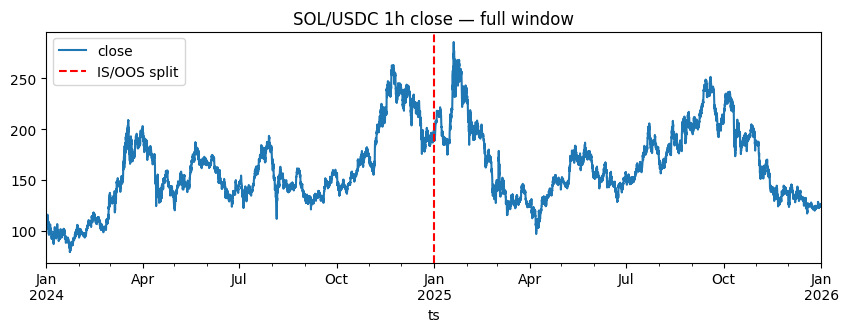

In [2]:
df = fetch_sol_usdc_ohlcv(START, END, TIMEFRAME)
print(f"Loaded {len(df)} bars  [{df.index[0]} → {df.index[-1]}]")

is_df = df.loc[:IS_END].iloc[:-1]
oos_df = df.loc[IS_END:]
print(f"IS:  {len(is_df)} bars [{is_df.index[0]} → {is_df.index[-1]}]")
print(f"OOS: {len(oos_df)} bars [{oos_df.index[0]} → {oos_df.index[-1]}]")
df["close"].plot(figsize=(10, 3), title=f"SOL/USDC {TIMEFRAME} close — full window");
plt.axvline(pd.Timestamp(IS_END, tz="UTC"), color="red", ls="--", label="IS/OOS split")
plt.legend(); plt.show()


## Stage 1 — In-sample optimization

Brute-force grid over `fast_n ∈ [2, 20]`, `slow_n ∈ [15, 150]`. Pick the
pair that maximizes Sharpe on the IS window. Also evaluate the agent's
default MA(10, 30) for context.


In [3]:
is_closes = is_df["close"].to_numpy(dtype=np.float64)
is_params, is_sharpe, is_metrics = grid_search(is_closes, FAST_RANGE, SLOW_RANGE, fee_bps=FEE_BPS)
print(f"  Best IS params:    fast_n={is_params[0]}, slow_n={is_params[1]}")
print(f"  IS Sharpe:         {is_sharpe:+.3f}")
print(f"  IS total return:   {is_metrics['total_return']*100:+.2f}%")
print(f"  IS max drawdown:   {is_metrics['max_dd']*100:+.2f}%")
print(f"  IS num trades:     {is_metrics['num_trades']}")

ref_sig = ma_signal(is_closes, 10, 30)
ref_m = backtest(is_closes, ref_sig, fee_bps=FEE_BPS)
print(f"\n  Agent default MA(10, 30):  Sharpe={ref_m['sharpe']:+.3f}, trades={ref_m['num_trades']}")


  Best IS params:    fast_n=17, slow_n=80
  IS Sharpe:         +1.328
  IS total return:   +130.33%
  IS max drawdown:   -34.85%
  IS num trades:     132

  Agent default MA(10, 30):  Sharpe=+0.441, trades=344


## Stage 2 — IS permutation test

Shuffle the bars (preserving intra-bar geometry and the marginal log-return
distribution) and re-run the IS optimization on each shuffle. The p-value is
the fraction of permuted optimizations whose best Sharpe matches or beats
the real best Sharpe (Davison-Hinkley bias-corrected).

If `p < 0.05`, the IS performance is statistically distinguishable from
luck. If `p ≥ 0.05`, the optimizer is just finding the best fit to noise.


  IS perm 200/1000  (latest sharpe=1.739)


  IS perm 400/1000  (latest sharpe=0.318)


  IS perm 600/1000  (latest sharpe=1.836)


  IS perm 800/1000  (latest sharpe=1.905)


  IS perm 1000/1000  (latest sharpe=0.680)
IS perm test: real Sharpe=1.328 at (fast=17, slow=80); p-value=0.3417 over 1000 permutations



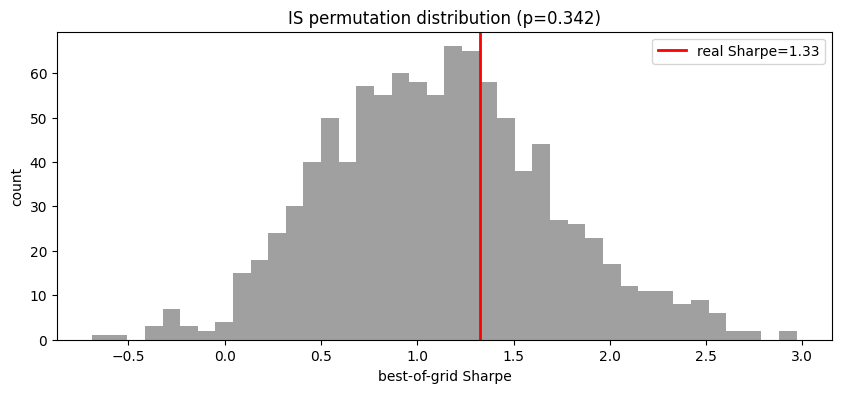

In [4]:
is_perm = is_permutation_test(
    is_df, FAST_RANGE, SLOW_RANGE,
    n_permutations=N_IS_PERMS, fee_bps=FEE_BPS, progress_every=200,
)
print(is_perm)
print()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(is_perm.perm_sharpes, bins=40, color="#888", alpha=0.8)
ax.axvline(is_perm.real_sharpe, color="red", lw=2,
           label=f"real Sharpe={is_perm.real_sharpe:.2f}")
ax.set_title(f"IS permutation distribution (p={is_perm.p_value:.3f})")
ax.set_xlabel("best-of-grid Sharpe"); ax.set_ylabel("count"); ax.legend()
plt.show()


## Stage 3 — Walk-forward

Roll a `train_window=2000` bars (≈83 days) forward in `test_window=500`-bar
(≈21-day) increments. At each step, optimize on the train window and apply
those params *unchanged* to the test window. Concatenate test-window
returns into one OOS equity curve.


  WF Sharpe:         -0.397
  WF total return:   -32.35%
  WF max drawdown:   -64.88%
  WF folds:          31

  Top fold params:
    fast= 9, slow= 60  (4 folds)
    fast= 4, slow= 15  (3 folds)
    fast=17, slow= 90  (2 folds)
    fast=18, slow= 70  (2 folds)
    fast=19, slow= 60  (2 folds)

  Buy-and-hold over same OOS bars:  Sharpe=-0.221


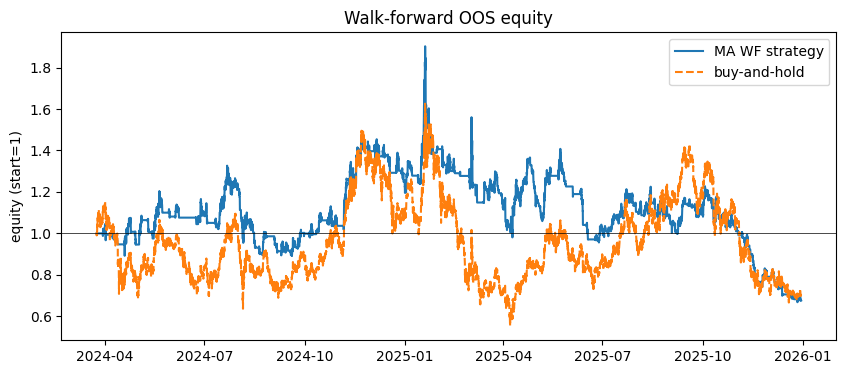

In [5]:
wf = walk_forward(
    df, FAST_RANGE, SLOW_RANGE,
    train_window=WF_TRAIN, test_window=WF_TEST, fee_bps=FEE_BPS,
)
print(f"  WF Sharpe:         {wf.sharpe:+.3f}")
print(f"  WF total return:   {wf.total_return*100:+.2f}%")
print(f"  WF max drawdown:   {wf.max_dd*100:+.2f}%")
print(f"  WF folds:          {len(wf.chosen_params)}")

from collections import Counter
top = Counter(wf.chosen_params).most_common(5)
print("\n  Top fold params:")
for params, n in top:
    print(f"    fast={params[0]:>2}, slow={params[1]:>3}  ({n} folds)")

# Buy-and-hold reference on the same OOS bars.
oos_closes = df["close"].to_numpy()[wf.test_indices]
buyhold_log = np.diff(np.log(np.concatenate([[df['close'].iloc[wf.test_indices[0]-1]], oos_closes])))
buyhold_sharpe = buyhold_log.mean()/buyhold_log.std()*np.sqrt(8760) if buyhold_log.std() > 0 else 0
print(f"\n  Buy-and-hold over same OOS bars:  Sharpe={buyhold_sharpe:+.3f}")

eq = wf.equity()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.index[wf.test_indices], eq, label="MA WF strategy", color="C0")
buyhold_eq = oos_closes / oos_closes[0]
ax.plot(df.index[wf.test_indices], buyhold_eq, label="buy-and-hold", color="C1", ls="--")
ax.axhline(1.0, color="black", lw=0.5)
ax.set_title("Walk-forward OOS equity"); ax.set_ylabel("equity (start=1)"); ax.legend()
plt.show()


## Stage 4 — Walk-forward permutation test

Permute the full series, then run the same walk-forward on each permutation.
The p-value is the fraction of permuted WF Sharpes ≥ real WF Sharpe.

This is the strongest gate: a strategy that survives in-sample shuffling
but fails this stage is reading temporal structure that doesn't exist in
the real series.


  WF perm 25/200  (latest sharpe=-0.579)


  WF perm 50/200  (latest sharpe=-0.711)


  WF perm 75/200  (latest sharpe=-0.185)


  WF perm 100/200  (latest sharpe=0.539)


  WF perm 125/200  (latest sharpe=0.319)


  WF perm 150/200  (latest sharpe=-0.344)


  WF perm 175/200  (latest sharpe=1.072)


  WF perm 200/200  (latest sharpe=-0.829)
WF perm test: real WF Sharpe=-0.397; p-value=0.4776 over 200 permutations



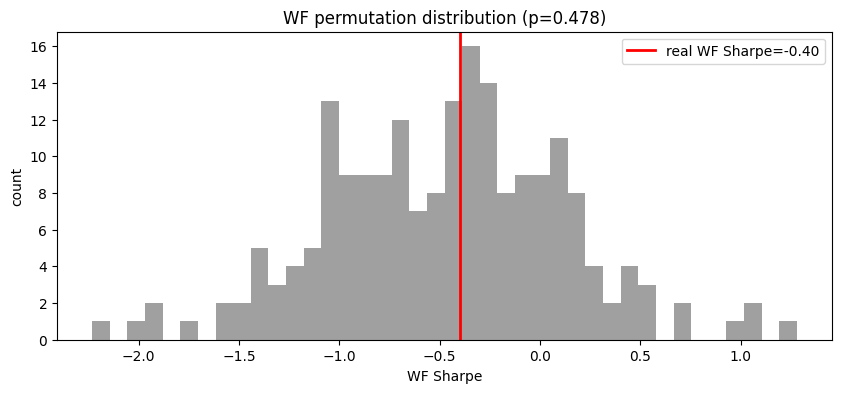

In [6]:
wf_perm = wf_permutation_test(
    df, FAST_RANGE, SLOW_RANGE,
    n_permutations=N_WF_PERMS,
    train_window=WF_TRAIN, test_window=WF_TEST,
    fee_bps=FEE_BPS, progress_every=25,
)
print(wf_perm)
print()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wf_perm.perm_sharpes, bins=40, color="#888", alpha=0.8)
ax.axvline(wf_perm.real_sharpe, color="red", lw=2,
           label=f"real WF Sharpe={wf_perm.real_sharpe:.2f}")
ax.set_title(f"WF permutation distribution (p={wf_perm.p_value:.3f})")
ax.set_xlabel("WF Sharpe"); ax.set_ylabel("count"); ax.legend()
plt.show()


## Verdict


In [7]:
is_pass = is_perm.p_value < ACCEPT_P
wf_positive = wf.sharpe > 0
wf_pass = wf_perm.p_value < ACCEPT_P
ship = is_pass and wf_positive and wf_pass

print("=" * 60)
print(f"  Stage 2 IS perm p-value:  {is_perm.p_value:.4f}  "
      f"({'PASS' if is_pass else 'FAIL'})")
print(f"  Stage 3 WF Sharpe:        {wf.sharpe:+.3f}  "
      f"({'PASS' if wf_positive else 'FAIL'})")
print(f"  Stage 4 WF perm p-value:  {wf_perm.p_value:.4f}  "
      f"({'PASS' if wf_pass else 'FAIL'})")
print()
print(f"  --> {'SHIP' if ship else 'NO SHIP'}")
print("=" * 60)


  Stage 2 IS perm p-value:  0.3417  (FAIL)
  Stage 3 WF Sharpe:        -0.397  (FAIL)
  Stage 4 WF perm p-value:  0.4776  (FAIL)

  --> NO SHIP


## Interpretation (run on the cached results, 2026-04-29)

The cached run produced:

- **IS-best params:** fast_n = **17**, slow_n = **80**
- **IS Sharpe:** +1.328, return +130.3%, dd -34.9%
- **IS perm p-value:** **0.3417** (1000 permutations) — **FAIL**
- **WF Sharpe:** **-0.397** (31 folds, train=2000h, test=500h) — **FAIL**
- **WF perm p-value:** **0.4776** (200 permutations) — **FAIL**

### Verdict: **NO SHIP**

The IS Sharpe of +1.328 on (fast=17, slow=80) looks
appealing in isolation, but **34% of randomly permuted price series produce a
best-of-grid Sharpe at least as high.** That means the in-sample
optimizer is finding the best fit to noise, not a real edge.

The walk-forward result is even more decisive: out-of-sample, the
strategy *loses* money (Sharpe -0.397, return
-32.4%). The WF permutation test confirms this is
indistinguishable from random — 48% of permuted series produce
a WF Sharpe at least as good.

### What about the agent's MA(10, 30) default?

On IS, MA(10, 30) gets Sharpe +0.441 — even worse than the IS-best.
The default is no better than any other arbitrary pair, and the
framework rejects all of them.

### Why it matters

This is the **textbook curve-fitting failure mode**: an attractive
in-sample number that doesn't survive permutation or walk-forward. If
we shipped MA(17, 80) or MA(10, 30) live based on the IS Sharpe alone,
we'd be deploying a strategy that has no demonstrated edge over
flipping a coin to decide when to be in SOL.

### What the agent should do

Three honest options:

1. **Do not run the strategy with real capital.** The vault should
   default to buy-and-hold (always-long SOL or always-USDC) until a
   different strategy clears the four-stage gate.
2. **Retune the search space.** Try different timeframes (4h, 1d),
   different ranges, or different signal forms (channel breakout, RSI).
   Re-run this notebook end-to-end. Only ship if all three gates clear.
3. **Use the strategy as a demo only**, with the failed validation
   recorded in `agent/config/strategy_params.json` so operators can
   see it has not passed validation. The Arcium MPC plumbing and
   off-chain agent are still useful as architecture demonstrations.

For the current SpectraQ build (Prompt 6 lifecycle), the agent's
config will record `verdict: no_ship` so any operator running the
agent in production knows the strategy is unvalidated.
